In [ ]:
## 🔬 Ultra-Complex Stock Price Model


## Feature Categories
### 🧠 1. **Technical Indicators**

```plaintext
- RSI, MACD, MACD Signal, SMA (5/20/50/200), EMA (12/26), Bollinger Bands (width, %B)
- ADX, ATR, CCI, MFI, OBV, Stochastic %K, %D, Ichimoku (cloud, base line)
- Price Rate of Change (ROC), Momentum
- Golden Cross/Death Cross Flags
```

---

### 📉 2. **Fundamental Metrics**

```plaintext
- EPS (trailing/forward), P/E, PEG, P/B, P/S, EV/EBITDA
- Revenue Growth (QoQ, YoY), EBITDA Margin, Net Profit Margin, ROE, ROA
- Dividend Yield, Dividend Stability, Free Cash Flow Yield, Buyback Yield
- Debt to Equity, Interest Coverage Ratio
- Insider Holdings %, Institutional Holdings %, Ownership Changes
```

---

### 🌍 3. **Macroeconomic Indicators**

```plaintext
- CPI, PPI, Core Inflation, Retail Sales, Consumer Confidence, Unemployment Rate
- Interest Rate (Fed Funds), Real Interest Rate, Yield Curve (10Y–2Y spread)
- Crude Oil, Gold, Copper, Natural Gas Prices
- USD Index (DXY), Currency Pair Exposure (USD/JPY, EUR/USD, INR/USD, etc.)
- GDP Growth (US + Global), PMI (Manufacturing/Services), VIX (Volatility Index)
- Central Bank Signals (Fed, ECB, BoJ), Trade Balance, Fiscal Policy Shift Flag
```

---

### 📊 4. **Market Microstructure & Flow**

```plaintext
- Volume Change %, Order Book Depth, VWAP Deviation
- Ask-Bid Spread, Dark Pool Activity %, HFT Volume %, Block Trade Activity
- Short Interest %, Put/Call Ratio, Gamma Exposure (GEX), Delta Exposure
- Options Open Interest Change, IV Rank/Percentile, Skew, Term Structure
- ETF Rebalancing Impact, Margin Debt, Repo Liquidity Indicators
```

---

### 🗞️ 5. **Sentiment & News Data**

```plaintext
- News Sentiment Score (Quantified), Twitter/Reddit Mentions, Social Volume & Sentiment
- Analyst Consensus (Buy/Hold/Sell), Rating Upgrades/Downgrades, Target Price Shift
- CEO/CFO Commentary Sentiment (NLP), Press Conference Event Flag
- Insider Buy/Sell Activity (Amount & Intent), Lawsuit/Regulatory Action Flag
- Retail Trader Sentiment Score (e.g., from StockTwits/WallStreetBets)
```

---

### 🧬 6. **Stock-Specific Events**

```plaintext
- Earnings Beat/Miss Magnitude, Revenue Beat/Miss, Forward Guidance Delta
- Product Launch Flag, M&A Announcement Impact Score
- Patent Filing/Expiry, FDA Approval Flag, Litigation Score
- Stock Split, Buyback Announcement, Dividend Declaration
- Management Resignation/Appointment
```

---

### 🛰️ 7. **Geopolitical & External Risks**

```plaintext
- War Tension Index, Cyberattack Index, Sanctions Risk
- Country-Specific Political Risk Score (e.g., China Risk)
- Global Risk Indicator (Black Swan Estimate, Tail Risk Score)
- Global Supply Chain Stress Index, Trade War Tension Index
- Natural Disaster Impact Score (Quake, Pandemic, Climate Crisis)
```

---



In [22]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from data_fetcher import load_stock_data,get_ticker
from pattern_detector import Tool
import plotly.graph_objs as go
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
from torch.functional import F

In [19]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))

1. Data Processing:
You’ll need to preprocess your raw stock data and compute the technical indicators. There are libraries like TA-Lib or pandas_ta that can help with this.

2. Fine-tuning:
Experiment with different number of indicators per group, hidden dimensions, and LSTM layers. Regularization (like dropout) can also be very important for avoiding overfitting, especially with many indicators.


1. FeatureCombiner:
Accepts a list of tensors, each containing features for a specific indicator group (e.g., trend, volume, etc.).
Learnable weights are applied to each indicator inside the group to compute a weighted sum.
Uses softmax to normalize the weights — so the model learns how to weigh the indicators for each group effectively.

2. LSTM + Attention:
The reduced feature set (after combining the indicators) is fed into an LSTM with attention.
The attention mechanism will focus on important time steps in the sequence, allowing the model to capture relevant patterns for decision-making.

3. Model Integration:
TradingModel integrates the two components: FeatureCombiner and LSTM + Attention.
You can now pass sequences of feature groups (e.g., trend, volume, etc.) and receive predictions like Buy, Sell, Hold.

In [12]:
# Step 1: FeatureCombiner (learnable weights for indicator groups)
class FeatureCombiner(nn.Module):
    def __init__(self, num_indicators_per_group):
        super(FeatureCombiner, self).__init__()
        
        # One weight per indicator inside each group
        self.weights = nn.ParameterList([
            nn.Parameter(torch.randn(n)) for n in num_indicators_per_group
        ])
    
    def forward(self, feature_groups):
        """
        feature_groups: list of tensors, each (batch_size, seq_len, num_indicators_in_group)
        """
        combined_features = []
        
        for features, weight in zip(feature_groups, self.weights):
            # Normalize the weights (softmax over indicators in group)
            softmax_weight = torch.softmax(weight, dim=0) # (num_indicators_in_group)
            # Weighted sum for each group
            weighted_feature = torch.sum(features * softmax_weight, dim=-1) # (batch_size, seq_len)
            combined_features.append(weighted_feature.unsqueeze(-1)) # (batch_size, seq_len, 1)
        
        # Concatenate all groups together (combine into one feature vector)
        combined_output = torch.cat(combined_features, dim=-1) # (batch_size, seq_len, num_groups)
        return combined_output

In [18]:
# Define the Transformer model
class TransformerModel(nn.Module):
    def __init__(self, input_len, n_features, output_len, d_model=64, num_heads=8, num_layers=6, use_attention=True,model_path="transformer_stock_model.pth"):
        super(TransformerModel, self).__init__()
        
        self.input_len = input_len
        self.n_features = n_features
        self.output_len = output_len
        self.use_attention = use_attention
        self.model_path=model_path
        
        # Model layers
        self.embedding = nn.Linear(n_features, d_model)  # Embedding layer to convert input into d_model dimension
        self.positional_encoding = nn.Parameter(torch.zeros(1, input_len, d_model))  # Positional Encoding
        
        # Transformer Encoder and Decoder layers
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads),
            num_layers=num_layers
        )
        
        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(d_model=d_model, nhead=num_heads),
            num_layers=num_layers
        )
        
        # # Attention layer if specified
        # if use_attention:
        #     self.attention = Attention(d_model)
        
        # Output fully connected layer
        self.fc = nn.Linear(d_model, output_len)

    def forward(self, x):
        # x: [batch_size, seq_len, n_features]
        x = self.embedding(x) + self.positional_encoding  # Add positional encoding
        
        # Transformer expects inputs in shape [seq_len, batch_size, d_model]
        x = x.permute(1, 0, 2)  # [batch_size, seq_len, d_model] -> [seq_len, batch_size, d_model]
        
        # Transformer Encoder
        encoder_output = self.encoder(x)
        
        # If attention is used, apply it after the encoder
        # if self.use_attention:
        #     encoder_output, attention_weights = self.attention(encoder_output)
        
        # For the decoder, we use the encoder output and target sequence (e.g., for seq2seq tasks)
        # Here we assume the target sequence is the same as the input sequence (for simplicity)
        decoder_output = self.decoder(encoder_output, encoder_output)
        
        # Get the output from the last time step
        # decoder_output = decoder_output[-1, :, :]
        
        # Output layer
        out = self.fc(decoder_output)
        return out
        
    def save_model(self):
        torch.save(self.state_dict(), self.model_path)
        print(f"✅ Model saved at {self.model_path}")

    def load_model(self):
        self.load_state_dict(torch.load(self.model_path))
        self.eval()
        print(f"✅ Model loaded from {self.model_path}")

In [19]:
# Attention Mechanism
class Attention(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(input_dim, hidden_dim)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, lstm_output):
        # Attention mechanism
        attn_weights = self.attn(lstm_output)
        scores = self.tanh(attn_weights)
        attn_weights = self.softmax(attn_weights)
        weighted_sum = torch.sum(attn_weights * lstm_output, dim=1)
        return weighted_sum

# LSTM with Attention Model
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,num_layers=1, dropout=0.2,use_attention=False):
        super().__init__()
        self.use_attention = use_attention
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        if use_attention:
            self.attention = Attention(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        if self.use_attention:
            # Context vector: weighted sum of LSTM outputs
            out = self.attention(lstm_out)  # shape: [batch, hidden_size]
        else:
            # Use the output of the last timestep: [batch, hidden_size]
            out = lstm_out[:, -1, :]
        out = self.fc(out)
        return out
    def save_model(self):
        torch.save(self.state_dict(), self.model_path)
        print(f"✅ Model saved at {self.model_path}")

    def load_model(self):
        self.load_state_dict(torch.load(self.model_path))
        self.eval()
        print(f"✅ Model loaded from {self.model_path}")

In [14]:
# Full model combining FeatureCombiner and LSTM with Attention
class TradingModel(nn.Module):
    def __init__(self, input_dims_per_group, hidden_dim=64, num_lstm_layers=1, output_dim=3):
        super(TradingModel, self).__init__()
        
        # Initialize feature combiner for each group
        self.feature_combiner = FeatureCombiner(input_dims_per_group)
        
        # LSTM + Attention model for final decision
        self.lstm_attention_model = LSTMWithAttention(
            input_dim=len(input_dims_per_group), # num_groups
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            num_layers=num_lstm_layers
        )
    
    def forward(self, feature_groups):
        # Combine indicators within each group
        combined_features = self.feature_combiner(feature_groups)
        
        # Pass combined features to LSTM + Attention model
        output = self.lstm_attention_model(combined_features)
        
        return output

In [ ]:
def generate(n_days):
    for i in range(n_days/10):
        ## Get the stock data
        status,train_data = load_stock_data("WAAREEENER.NS",interval='5m',start="2025-03-01",end="2025-04-23",refresh=True)
        ## Get the stock data
        status,test_data = load_stock_data("WAAREEENER.NS",interval='5m',start="2025-04-24",end="2025-04-25",refresh=True)
        train_size,trainX,trainY = generate_data(train_data)
        test_size,testX,testY = generate_data(test_data)


In [20]:
# Function to create sequences
def create_sequences(data,output_idx=None, seq_length=50):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        if output_idx is not None:
            y.append(data[i+seq_length,output_idx])
        else:
            y.append(data[i+seq_length])
    return np.array(X), np.array(y)

def preprocess_data(data,input_len,output_len,output_data=None,output_col="Output", load_scaler = False,fit_scaler=True,scaler_path="scaler.pkl"):    
    if load_scaler and os.path.exists(scaler_path):
        scaler = joblib.load(scaler_path)
        print("✅ Scaler loaded.")
    else:
        scaler = MinMaxScaler()
        fit_scaler = True

    if fit_scaler:
        data_scaled = scaler.fit_transform(data)
        joblib.dump(scaler, scaler_path)  # Save after fitting
        print("✅ Scaler fitted and saved.")
    else:
        data_scaled = scaler.transform(data)

    # Generate time series seq
    if output_data is not None:
        n_examples,n_features = data.shape
        n_samples = n_examples - input_len - output_len
        X = np.zeros((n_samples,input_len,n_features))
        y = np.zeros((n_samples,output_len))
        
        for i in range(n_samples):
            X[i] = data[i:i+input_len, :]
            y[i] = output_data[i+input_len]
        
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        return TensorDataset(X_tensor, y_tensor)
        
    # Get the last input_len items
    X = data[-input_len:]
    return torch.tensor(X, dtype=torch.float32)

In [74]:
def create_test_dataset(n_examples,n_features,input_seq_length=50,output_seq_length=1):
    # Simulate some data for time series (you can replace this with your actual dataset)
    data = np.sin(np.linspace(0, 100, 1000))  # Example: sine wave
    data = data.reshape(-1, 1)
    plt.plot(data)
    plt.title("data pattern")
    plt.show()

    data_scaled = scaler.fit_transform(data)
    plt.plot(data_scaled)
    plt.title("Scales data")
    plt.show()

    X, y = create_sequences(data_scaled, input_seq_length)
    n_batches,*_ = X.shape

    print("No. of examples :",n_examples)
    print("No. of features :",n_features)
    print("No. of batches :",n_batches)
    print("Input sequence length :",input_seq_length)
    print("Output sequence length :",output_seq_length)

    # Convert data to PyTorch tensors
    X_tensor = torch.tensor(X.reshape(n_batches,input_seq_length,n_features), dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(n_batches,output_seq_length), dtype=torch.float32)

    # Split into training and test sets
    train_size = int(len(X_tensor) * 0.8)
    X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
    y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]
    y_test = y_test.numpy()

    return X_train,y_train,X_test,y_test
def plot_candlesticks(data):
    fig = go.Figure(data=[
        go.Candlestick(x=data.index, open=data['Open'], high=data['High'],
                       low=data['Low'], close=data['Close'], name="Candles")
    ])
    fig.update_layout(title="Prive vs Time", xaxis_title="Time", yaxis_title="Price")
    fig.show()

def create_dataset(ticker,interval="2m",period="1d",input_seq_length=50,output_seq_length=1,plot=False):
    status,data = load_stock_data(ticker,interval=interval,period=period,refresh=True)
    if plot:
        plot_candlesticks(data)

    data_scaled = scaler.fit_transform(data.values)
    n_examples,n_features = data.shape
    X,y = create_sequences(data_scaled,output_idx=0,seq_length=input_seq_length)
    n_batches,*_ = X.shape

    print("No. of examples :",n_examples)
    print("No. of features :",n_features)
    print("No. of batches :",n_batches)
    print("Input sequence length :",input_seq_length)
    print("Output sequence length :",output_seq_length)

    # Convert data to PyTorch tensors
    X_tensor = torch.tensor(X.reshape(n_batches,input_seq_length,n_features), dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(n_batches,output_seq_length), dtype=torch.float32)

    # Split into training and test sets
    train_size = int(len(X_tensor) * 0.8)
    X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
    y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]
    y_test = y_test.numpy()

    return X_train,y_train,X_test,y_test

In [75]:
def train(model,criterion,optimizer,X_train,y_train,epochs=10):
    history = []
    # Training the model
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass
        y_pred = model(X_train)
        
        # Compute loss
        loss = criterion(y_pred, y_train)
        history.append(loss.item())
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        if (epoch+1) % 1 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}',end="\r")
    return np.array(history)

In [76]:
def test(model,X_test,y_test,plot=True):
    # Predict on the test set
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).numpy()

    y_dummy = np.zeros((y_test.shape[0],X_test.shape[-1]))
    
    y_dummy[:,[0]] = y_pred
    y_pred_dummy = scaler.inverse_transform(y_dummy)
    y_pred_actual = y_pred_dummy[:,0]
    
    y_dummy[:,[0]] = y_test
    y_test_dummy = scaler.inverse_transform(y_dummy)
    y_test_actual = y_test_dummy[:,0]

    if plot:
        # Plot the results
        plt.figure(figsize=(10, 6))
        plt.plot(y_test_actual, label='Actual')
        plt.plot(y_pred_actual, label='Predicted')
        plt.legend()
        plt.title('Time Series Forecasting with LSTM + Attention (PyTorch)')
        plt.show()
        
    return pd.DataFrame({"actual":y_test_actual.flatten(),"predicted": y_pred_actual.flatten()})

In [84]:
class Params:
    N_EXAMPLES = 1000
    N_FEATURES = 5
    HIDDEN_SIZE = 64
    INPUT_SEQUENCE_LENGTH  = 60
    OUTPUT_SEQUENCE_LENGTH = 1
    LEARNING_RATE = 0.005
    EPOCS  =  200 
    USE_ATTENTION = True
    MODEL_FILE_NAME = "lstm_model.pth"
    RESULTS_FILE_NAME = "results.csv"
    TICKER="GRSE.NS"
    INTERVAL="1m"
    PERIOD="8d"
    

In [85]:
def get_results(model_class,file_name,params:Params,X_train,y_train,X_test,y_test ): 
    # Model initialization
    model = model_class(input_size=params.N_FEATURES, hidden_size=params.HIDDEN_SIZE, output_size=params.OUTPUT_SEQUENCE_LENGTH,use_attention=params.USE_ATTENTION)
    
    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params.LEARNING_RATE)
    
    # Plot loss
    history = train(model,criterion,optimizer,X_train,y_train,epochs=params.EPOCS)
    plt.plot(history)
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.show()
    
    # Plot test results
    res = test(model,X_test,y_test)
    
    res.to_csv(file_name)
    mse = mean_squared_error(res['actual'], res['predicted'])
    mae = mean_absolute_error(res['actual'], res['predicted'])
    rmse = np.sqrt(mse)
    r2 = r2_score(res['actual'], res['predicted'])

    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    with open(params.RESULTS_FILE_NAME,'w') as f:
        print(f"MAE: {mae:.4f}",file=f)
        print(f"MSE: {mse:.4f}",file=f)
        print(f"RMSE: {rmse:.4f}",file=f)
        print(f"R² Score: {r2:.4f}",file=f)

In [86]:
def classifier_model(expected_profit,indicators,threshold_buy=0.8,threshold_sell=0.2):
    expected_profit = future_price - current_price
    # Threshold-based classification
    if expected_profit > threshold_buy:
        action = "Buy"
    elif expected_profit < -threshold_sell:
        action = "Sell"
    else:
        action = "Hold"

In [10]:
# Example usage
if __name__ == "__main_":
    batch_size = 32
    seq_len = 60 # example: last 60 minutes of data
    input_dims_per_group = [4, 3, 2, 3] # example: 4 trend indicators, 3 momentum, 2 volume, 3 volatility
    
    # Create the model
    model = TradingModel(input_dims_per_group=input_dims_per_group)
    print(model)

    # Dummy input to test (feature_groups is a list of tensors, each (batch_size, seq_len, num_indicators_in_group))
    feature_groups = [
        torch.randn(batch_size, seq_len, n) for n in input_dims_per_group
    ]
    
    dummy_output = model(feature_groups)
    print("Output shape:", dummy_output.shape) # Should be (batch_size, 3)

In [11]:
def optimize_model():# Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Example training loop
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
    
        # Assuming 'feature_groups' is your data and 'targets' is the true label (buy, sell, hold)
        outputs = model(feature_groups)
        targets = torch.randint(0, 3, (batch_size,)) # Fake targets for testing
    
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
    
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item()}")

In [81]:
X_train,y_train,X_test,y_test = create_dataset(Params.TICKER,Params.INTERVAL,Params.PERIOD,Params.INPUT_SEQUENCE_LENGTH,Params.OUTPUT_SEQUENCE_LENGTH)

[*********************100%***********************]  1 of 1 completed

✅ Successfully downloaded data for GRSE.NS
No. of examples : 3000
No. of features : 5
No. of batches : 2940
Input sequence length : 60
Output sequence length : 1


Epoch [200/200], Loss: 0.0012

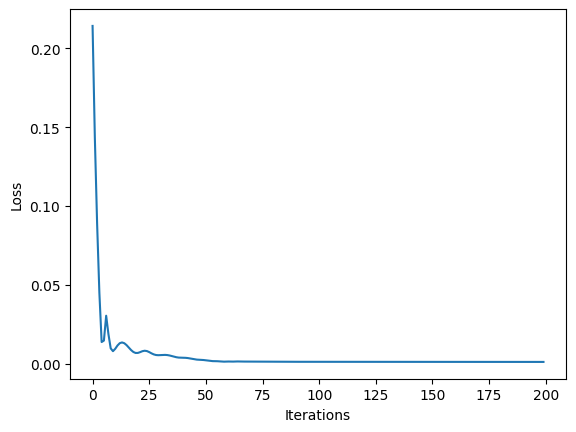

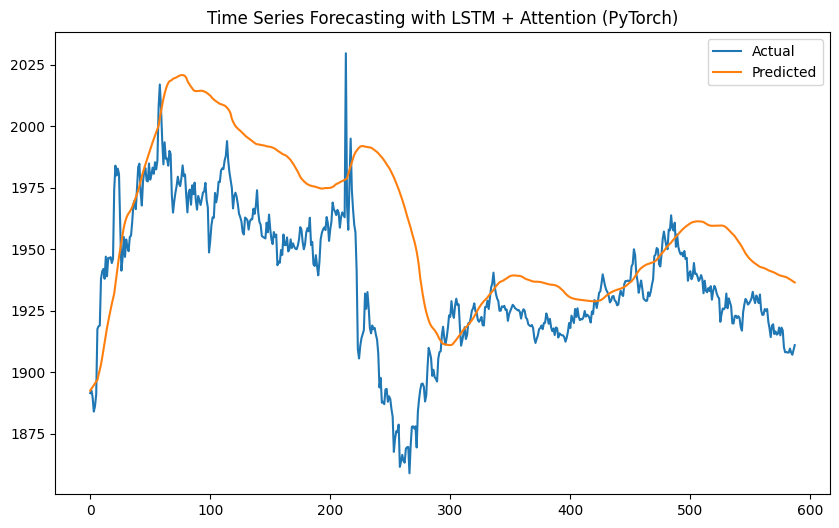

MAE: 25.3677
MSE: 1184.6987
RMSE: 34.4195
R² Score: -0.5380


In [87]:
get_results(LSTM,"lstm_params.txt",Params,X_train,y_train,X_test,y_test)

Fantastic! Fine-tuning your model and performing backtesting is essential for improving its performance and ensuring it works effectively with real-world data.

Step 1: Fine-Tuning the Model
Fine-tuning involves adjusting the hyperparameters and model architecture to get the best performance for your specific problem.
Key Steps for Fine-Tuning:

1. Hyperparameter Tuning:
Learning Rate: The most crucial hyperparameter for training.
Start with lr = 0.001 and try values in the range of 1e-5 to 1e-2 using a learning rate scheduler or grid search.

Hidden Dimension: Increasing this value allows the model to learn more complex features.
Try hidden_dim = 64, 128, or even 256 based on your dataset size.
             
Batch Size: Larger batches tend to make the model converge faster, but you need more memory.
Try experimenting with batch_size = 32, 64, or 128.
             
Dropout: A regularization method to prevent overfitting.
Try values like 0.2, 0.3, or 0.5.

2. Training Length:
Train the model for a sufficient number of epochs (e.g., 20–50).
Use an early stopping mechanism to prevent overfitting. You can track the validation loss and stop when it starts increasing.

3. Cross-validation:
Split the dataset into training, validation, and test sets.
Perform k-fold cross-validation to ensure your model generalizes well to unseen data.

4. Optimizer:
Use Adam optimizer (as in the code) for most cases.
Try experimenting with learning rate schedules like ReduceLROnPlateau or CosineAnnealing.

Step 2: Backtesting the Model

Backtesting allows you to simulate how your model would have performed in the past using historical stock data. This helps evaluate your strategy before risking real money.
Key Steps for Backtesting:

1. Backtest Framework:
Set up a backtest framework that simulates buy/sell/hold decisions based on model predictions.
Track portfolio performance: profit, drawdown, etc.

2. Backtest Setup:
You’ll need a historical stock dataset. You can use libraries like yfinance or Quandl to get historical stock data.

3. Signal Generation:
Convert the model's Buy/Sell/Hold outputs into actual trade signals (e.g., buy when output is 1, sell when 2, hold when 0).

4. Portfolio Management:
Track your portfolio's value as you execute trades:
Initial capital (e.g., $10,000).
Position size (e.g., 1 stock per trade, 10% of portfolio, etc.).
Transaction costs (e.g., 0.1% fee per trade).
You can also implement risk management features like stop-loss, take-profit, and position sizing.

5. Performance Metrics:
Calculate key metrics like:
Total return
Annualized return
Max drawdown
Sharpe ratio (risk-adjusted return)
Profit Factor

This gives you an idea of how well your model performs.

In [16]:
# Function to simulate trading decisions
def generate_signals(predictions):
    # Buy when predicted '1', sell when predicted '2', hold when predicted '0'
    return predictions.argmax(dim=1).cpu().numpy()

# Backtest function
def backtest(model, stock_symbol, start_date, end_date, initial_capital=10000, transaction_fee=0.001):
    # Download stock data (using adjusted close price)
    data = yf.download(stock_symbol, start=start_date, end=end_date)
    data['Signal'] = 0 # Default signal is "Hold"

    # Prepare the dataset
    seq_len = 60 # Length of the input sequence
    feature_groups = [torch.randn(len(data), seq_len, 4), torch.randn(len(data), seq_len, 3)] # Example feature groups
    
    # Assuming the model has been trained and ready
    model.eval()
    
    # Generate trading signals
    with torch.no_grad():
        predictions = model(feature_groups)
        signals = generate_signals(predictions)

    data['Signal'] = signals
    
    # Simulate trading with an initial capital
    capital = initial_capital
    position = 0 # Number of stocks in possession
    portfolio_value = []
    
    for i in range(len(data)):
        # Check the signal and take action
        if data['Signal'].iloc[i] == 1: # Buy signal
            if capital >= data['Close'].iloc[i]:
                position = capital // data['Close'].iloc[i]
                capital -= position * data['Close'].iloc[i]
        elif data['Signal'].iloc[i] == 2: # Sell signal
            capital += position * data['Close'].iloc[i] * (1 - transaction_fee)
            position = 0 # Sell all stocks
        
        # Record portfolio value
        portfolio_value.append(capital + position * data['Close'].iloc[i])

    data['Portfolio_Value'] = portfolio_value
    return data


In [17]:
if __name__ == "test":
    # Example of running the backtest
    model = TradingModel(input_dims_per_group=[4, 3, 2, 3])
    backtest_results = backtest(model, stock_symbol='AAPL', start_date='2020-01-01', end_date='2021-01-01')
    
    # Plot portfolio value
    import matplotlib.pyplot as plt
    plt.plot(backtest_results['Portfolio_Value'])
    plt.title('Backtest Portfolio Value')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value')
    plt.show()

    """Performance Evaluation:
    Once you’ve executed the backtest, you can evaluate the results using several key performance metrics.
    Common Metrics:"""
    #1. Total Return:
    total_return = (backtest_results['Portfolio_Value'].iloc[-1] - initial_capital) / initial_capital
    print(f'Total Return: {total_return * 100:.2f}%')
    
    
    #2. Maximum Drawdown:
    rolling_max = backtest_results['Portfolio_Value'].cummax()
    daily_drawdown = backtest_results['Portfolio_Value'] / rolling_max - 1
    max_drawdown = daily_drawdown.min()
    print(f'Maximum Drawdown: {max_drawdown * 100:.2f}%')
    
    
    #3. Sharpe Ratio (risk-adjusted return):
    daily_returns = backtest_results['Portfolio_Value'].pct_change().dropna()
    sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252) # Annualized
    print(f'Sharpe Ratio: {sharpe_ratio:.2f}')

Conclusion and Next Steps:

1. Fine-Tuning:
Experiment with different hyperparameters and training lengths to improve model performance.
Use early stopping to prevent overfitting during training.

2. Backtesting:
After training, backtest your model on historical data to see how it would have performed in the past.
Adjust your risk management and portfolio size for better returns.
A
3. Live Deployment (optional for advanced users):
Once backtesting results are satisfactory, consider setting up a paper trading environment for live simulation or actual trading with real-time data.